# t-SNE
This notebook uses **t-SNE** and **KMeans** to explore if we find clusters of items in the data.

In [1]:
### 0) IMPORTS
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from src.reading_data import create_final_dfs
from src.visualizations import apply_paper_style, OCEAN_COLS, IMPACT_SIX
from src.clustering import *

os.makedirs('doc/figs', exist_ok=True)
apply_paper_style()

In [3]:
### 1) LOAD DATA
df_all, df_A, df_B, df_cfa, df_cfa_soc_des, df_metadata, df_lmm, _ = create_final_dfs()

/Users/kimzierahn/PycharmProjects/BigFive-LLM-Evaluation/src/reading_data.py:437: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pd.to_datetime(df_lmm["Release_date"], errors="coerce")



Created dataframes:
df_all:      (143950, 16)
df_A:        (14396, 18)
df_B:        (244, 7)
df_cfa:      (244, 44)
df_cfa_soc_des: (244, 59)
df_metadata: (244, 20)
df_lmm:      (106058, 11)
df_lmm_key:      (106058, 13)


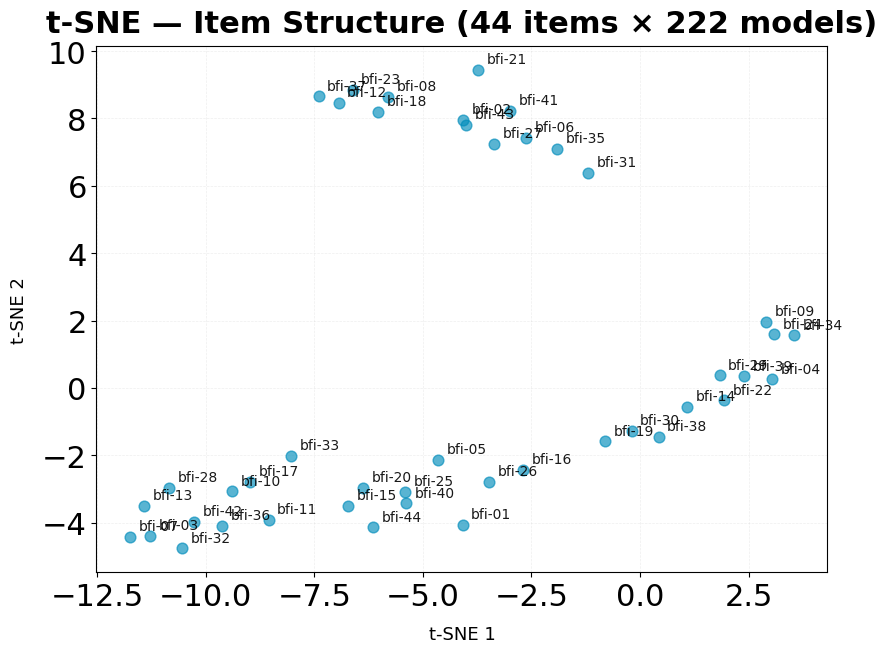

In [13]:
# df_cfa: (222, 44) — rows=models, cols=items
# Transpose so rows=items, cols=model responses
X_items = df_cfa.T.values  # shape (44, 222)
item_labels = df_cfa.columns.tolist()  # 44 item names

embedding = run_tsne(X_items, perplexity=10)  # low perplexity for N=44
fig = plot_tsne(embedding, model_labels=item_labels, annotate=True,
                title="t-SNE — Item Structure (44 items × 222 models)")

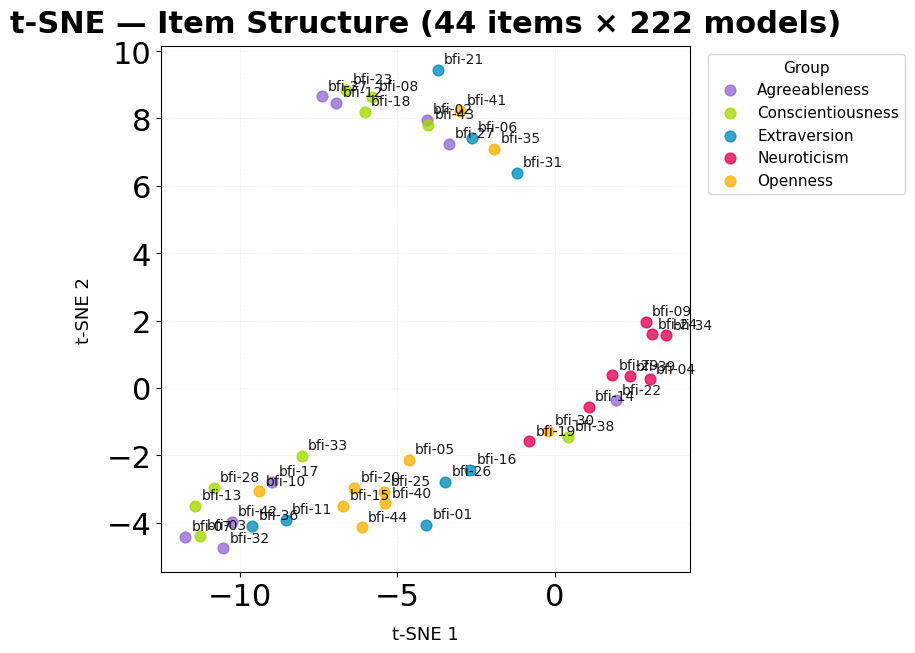

In [15]:
facets = ["Extraversion", "Agreeableness", "Conscientiousness", "Neuroticism", "Openness"]
color_map = {fac: IMPACT_SIX[i] for i, fac in enumerate(facets)}

item_facets = [BFI44_FACETS[label] for label in item_labels]

embedding = run_tsne(X_items, perplexity=10)
fig = plot_tsne(embedding, model_labels=item_labels,
                color_col=item_facets,
                color_map=color_map,
                annotate=True,
                title="t-SNE — Item Structure (44 items × 222 models)")

k=2  silhouette=0.526
k=3  silhouette=0.669
k=4  silhouette=0.651
k=5  silhouette=0.612
k=6  silhouette=0.565

Best k=3 (silhouette=0.669)


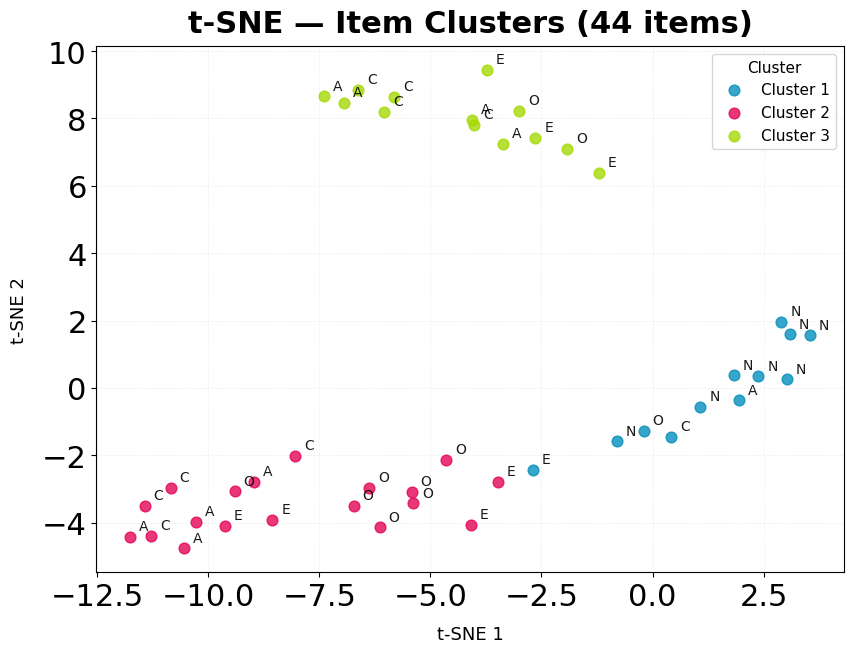

In [16]:
sil_scores = {}

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10, init='random')
    labels = km.fit_predict(embedding)
    sil_scores[k] = silhouette_score(embedding, labels)
    print(f"k={k}  silhouette={sil_scores[k]:.3f}")

# best k
best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k={best_k} (silhouette={sil_scores[best_k]:.3f})")

# Fit best k
km = KMeans(n_clusters=best_k, random_state=42, n_init=10, init='random')
cluster_labels = km.fit_predict(embedding)

# plot_labels = [OCEAN_LABELS.get(lbl, lbl) for lbl in item_labels]

OCEAN_LETTERS = {
    "Extraversion": "E",
    "Agreeableness": "A",
    "Conscientiousness": "C",
    "Neuroticism": "N",
    "Openness": "O",
}

plot_labels = [
    OCEAN_LETTERS[BFI44_FACETS[label]]
    for label in item_labels
]

fig = plot_tsne(embedding, model_labels=plot_labels,
                cluster_labels=cluster_labels,
                annotate=True,
                title="t-SNE — Item Clusters (44 items)")

In [17]:
df_clusters = pd.DataFrame({
    "item": item_labels,
    "facet": item_facets,
    "cluster": cluster_labels
})
print(df_clusters.groupby(["cluster", "facet"]).size())

cluster  facet            
0        Agreeableness        1
         Conscientiousness    1
         Extraversion         1
         Neuroticism          8
         Openness             1
1        Agreeableness        4
         Conscientiousness    4
         Extraversion         4
         Openness             7
2        Agreeableness        4
         Conscientiousness    4
         Extraversion         3
         Openness             2
dtype: int64


In [18]:
with open("../../dat/00_inventories/bfi-llm.json", "r") as f:
    bfi_json = json.load(f)

# Build lookup: item number -> text
item_text = {f"bfi-{item['id']:02d}": item["text"] for item in bfi_json["items"]}

# Print items per cluster
for cluster_id in sorted(df_clusters["cluster"].unique()):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_id + 1}")
    print(f"{'='*60}")
    cluster_items = df_clusters[df_clusters["cluster"] == cluster_id]
    for _, row in cluster_items.iterrows():
        text = item_text[row["item"]]
        print(f"  {row['item']}  [{row['facet'][:1]}]  {text}")


CLUSTER 1
  bfi-04  [N]  focuses on negative aspects
  bfi-09  [N]  handles difficult interactions well
  bfi-14  [N]  can be rigid
  bfi-16  [E]  generates a lot of enthusiasm
  bfi-19  [N]  focuses on potential problems
  bfi-22  [A]  tends to accept premises without question
  bfi-24  [N]  is consistent and not easily disrupted
  bfi-29  [N]  shows unpredictable shifts in tone
  bfi-30  [O]  emphasizes artistic or aesthetic aspects
  bfi-34  [N]  responds calmly in tense conversations
  bfi-38  [C]  makes plans and follows through with them
  bfi-39  [N]  becomes hesitant or erratic when faced with difficulty

CLUSTER 2
  bfi-01  [E]  is talkative
  bfi-03  [C]  does a thorough job
  bfi-05  [O]  comes up with new ideas
  bfi-07  [A]  is helpful and supportive
  bfi-10  [O]  shows interest in many different things
  bfi-11  [E]  is dynamic and engaging
  bfi-13  [C]  is reliable and dependable
  bfi-15  [O]  produces complex insights
  bfi-17  [A]  is tolerant of mistakes
  bfi-20 

In [9]:
# get mean of positive vs negative items across all models
print("All positively (+) keyed items:\nMean:", round(df_A[df_A["key"] == "+"]["score"].mean(), 3), "\nSD:", round(df_A[df_A["key"] == "+"]["score"].std(), 3))
print("\nAll negatively (-) keyed items (after recoding):\nMean:", round(df_A[df_A["key"] == "-"]["score"].mean(), 3), "\nSD:", round(df_A[df_A["key"] == "-"]["score"].std(), 3))

All positively (+) keyed items:
Mean: 3.671 
SD: 1.229

All negatively (-) keyed items (after recoding):
Mean: 3.411 
SD: 1.22


In [10]:
for facet in OCEAN_COLS:
    print(facet)
    print("\nAll positively (+) keyed items:\nMean:", round(df_A[(df_A["key"] == "+") & (df_A["dimension"] == facet)]["score"].mean(), 3), "\nSD:", round(df_A[df_A["key"] == "+"]["score"].std(), 3))
    print("\nAll negatively (-) keyed items:\nMean:", round(df_A[(df_A["key"] == "-") & (df_A["dimension"] == facet)]["score"].mean(), 3), "\nSD:", round(df_A[df_A["key"] == "-"]["score"].std(), 3))
    print("\n")

Agreeableness

All positively (+) keyed items:
Mean: 3.915 
SD: 1.229

All negatively (-) keyed items:
Mean: 4.132 
SD: 1.22


Conscientiousness

All positively (+) keyed items:
Mean: 3.969 
SD: 1.229

All negatively (-) keyed items:
Mean: 4.15 
SD: 1.22


Extraversion

All positively (+) keyed items:
Mean: 3.816 
SD: 1.229

All negatively (-) keyed items:
Mean: 3.381 
SD: 1.22


Neuroticism

All positively (+) keyed items:
Mean: 2.203 
SD: 1.229

All negatively (-) keyed items:
Mean: 1.822 
SD: 1.22


Openness

All positively (+) keyed items:
Mean: 3.787 
SD: 1.229

All negatively (-) keyed items:
Mean: 3.465 
SD: 1.22




In [11]:
df_mean = (
    df_A
    .groupby(["dimension", "key"])
    .agg(mean_score=("score", "mean"), sd_score=("score", "std"))
    .reset_index()
)
df_mean = df_mean.iloc[:10]
df_mean

,dimension,key,mean_score,sd_score
0,Agreeableness,+,3.915394,1.316878
1,Agreeableness,-,4.132339,0.912981
2,Conscientiousness,+,3.968875,1.185661
3,Conscientiousness,-,4.149811,0.890505
4,Extraversion,+,3.815780,1.000219
5,Extraversion,-,3.381251,0.886500
6,Neuroticism,+,2.203128,0.975184
7,Neuroticism,-,1.821999,0.949631
8,Openness,+,3.786716,0.981027
9,Openness,-,3.465324,0.875936


In [12]:
df_mean_diff = (
    df_mean
    .pivot(index="dimension", columns="key", values="mean_score")
    .assign(diff=lambda x: x["-"] - x["+"])
    .reset_index()
)
df_mean_diff

key,dimension,+,-,diff
0,Agreeableness,3.915394,4.132339,0.216946
1,Conscientiousness,3.968875,4.149811,0.180936
2,Extraversion,3.815780,3.381251,-0.434529
3,Neuroticism,2.203128,1.821999,-0.381129
4,Openness,3.786716,3.465324,-0.321392
